# Synthetic Data Generation & Privacy Evaluation: Census-Income (KDD) Dataset

**Library:** [NGO-Algorithm-Audit / python-synthpop](https://github.com/NGO-Algorithm-Audit/python-synthpop)  
**Dataset:** `census` as returned by `sdv.datasets.demo.download_demo(modality='single_table', dataset_name='census')` -- the UCI **Census-Income (KDD)** dataset (299,285 rows x 41 columns, 1994-95 Current Population Survey), reduced to a **50,000-row stratified sample** (due to compute limitations).

## Objectives
1. Generate high-quality synthetic data from the census dataset using python-synthpop's CART synthesizer.
2. Evaluate **five privacy metrics**:
   - Distance to Closest Record (DCR)
   - Overfitting Protection
   - Inference Risk
   - CM3 (Closest Match across Multiple Metrics)
   - Disclosure Protection
3. Design a **loss-aware optimisation strategy** with penalty terms for utility degradation and privacy leakage.
4. Evaluate the multi-objective loss function and analyse the utility-privacy trade-off.

> **Implementation notes (read before running).**
>
> **1. Three library bugs, fixed via subclassing:**
> `python-synthpop` v0.1.2's `DataProcessor` has three issues that surface on real-world categorical data with 10+ levels (common here: `education` has 17, `major industry code` 24, `country of birth` 43, `state of previous residence` 51):
> - `OneHotEncoder(sparse=...)` uses a scikit-learn kwarg removed in modern sklearn (renamed `sparse_output`) -> `TypeError`.
> - `_preprocess`'s final `data[self.original_columns]` reindex breaks once a categorical column has been expanded into multiple one-hot dummies (the original column name no longer exists) -> `KeyError`.
> - `_decode_categorical`'s argmax-based one-hot decode does not correct for the index shift introduced by `drop="first"`: `argmax` returns an index into the **surviving** `(n_categories - 1)` dummy columns, but the code maps it straight into the **full** `categories_` array. This silently decodes every non-baseline row to the *preceding* category and never recovers the last category at all -- verified empirically to inflate some categories by 10-20x and erase others (e.g. `'Doctorate degree'` distribution corrupted from a 0.66% true rate to ~24% synthetic in an early test).
>
> We fix all three with a `FixedDataProcessor` subclass below (overriding `_preprocess`, `_decode_categorical`, `postprocess`) and a small `FixedDisclosureProtection` subclass (the library's `DisclosureProtection.score()` has an unrelated, separate issue -- see note 2). `CARTMethod` itself needs no changes; it only consumes whatever clean numeric matrix `DataProcessor.preprocess()` produces.
>
> **2. Real-world duplicate rows affect threshold-based metrics.**
> ~15-25% of rows in this census data are exact duplicates of other rows (common in census microdata -- many people share identical quasi-identifier combinations, e.g. children with identical demographic codes). This means naive "Nth-percentile of real-to-real nearest-neighbor distance" thresholds (used by `OverfittingProtection` and the library's `DisclosureProtection`) collapse to exactly 0, which would silently make those scores a meaningless constant 1.0 regardless of synthesis quality. Both metrics below explicitly skip the zero-distance mass when computing their threshold, and report the duplicate rate as context.
>
> **3. Runtime.** Full-cardinality one-hot encoding expands 41 columns into ~310-370 predictor columns, and `CARTMethod` fits one decision tree per expanded column. At 50,000 rows this takes ~2.5-3 min for fit+sample. The privacy metrics use a stratified random subsample (10,000 rows, with a smaller 3,000-row subsample for the slower L1/Chebyshev distance computations in CM3) to keep nearest-neighbor search tractable. End-to-end this notebook takes roughly **30-35 minutes**, dominated by the 6-point lambda_p sweep in Section 6.

---

## 1. Imports & Setup

In [4]:
!pip install python-synthpop sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 11.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

from synthpop import MissingDataHandler, CARTMethod
from synthpop.processor.data_processor import DataProcessor
from synthpop.metrics import MetricsReport, DisclosureProtection

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All imports successful')

All imports successful


---
## 2. Load the Census Dataset & Reduce to 50,000 Rows

The `census` table from `sdv.datasets.demo` (downloaded via `download_demo(modality='single_table', dataset_name='census')`. Can be downloaded as csv to save time when rerunning the notebook.

We reduce to 50,000 rows using **stratified sampling on `label`** (the income indicator) rather than a plain random sample, so the original ~93.8% / 6.2% class imbalance is preserved exactly -- this matters because `label` is also the target we use for the Inference Risk metric later.

In [7]:
from sdv.datasets.demo import download_demo

#downloaded_demo = download_demo(modality='single_table', dataset_name='census')
#df_full = downloaded_demo[0]

df_full = pd.read_csv('census.csv')
print(f'Full dataset shape: {df_full.shape}')
print(f'\nLabel distribution (full data):')
print(df_full['label'].value_counts(normalize=True).round(4))

Full dataset shape: (299285, 41)

Label distribution (full data):
label
- 50000    0.938
50000+     0.062
Name: proportion, dtype: float64


In [8]:
N_TARGET = 50_000

real_df = (
    df_full.groupby('label', group_keys=False)
           .apply(lambda g: g.sample(int(round(N_TARGET * len(g) / len(df_full))), random_state=RANDOM_STATE),
                  include_groups=True)
           .sample(frac=1, random_state=RANDOM_STATE)
           .reset_index(drop=True)
)

print(f'Stratified sample shape: {real_df.shape}')
print(f'\nLabel distribution (50k sample) -- should match the full-data proportions above:')
print(real_df['label'].value_counts(normalize=True).round(4))

dup_rate_full = float(real_df.duplicated().mean())
print(f'\nExact duplicate row rate in this sample: {dup_rate_full:.1%}')

real_df.head()

Stratified sample shape: (50000, 41)

Label distribution (50k sample) -- should match the full-data proportions above:
label
- 50000    0.938
50000+     0.062
Name: proportion, dtype: float64

Exact duplicate row rate in this sample: 18.8%


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,3,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,Honduras,Honduras,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000
1,37,Not in universe,0,0,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000
2,49,Private,34,17,Masters degree(MA MS MEng MEd MSW MBA),0,Not in universe,Married-civilian spouse present,Finance insurance and real estate,Sales,...,Taiwan,Taiwan,Taiwan,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,94,- 50000
3,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,68,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000


In [9]:
print('=== Cardinality of categorical columns ===')
cardinality = real_df.select_dtypes(include='object').nunique().sort_values(ascending=False)
print(cardinality)
print(f'\n{(cardinality >= 10).sum()} of {len(cardinality)} categorical columns have >=10 levels')

=== Cardinality of categorical columns ===
state of previous residence                   51
country of birth mother                       43
country of birth father                       43
country of birth self                         43
detailed household and family stat            35
major industry code                           24
education                                     17
major occupation code                         15
migration code-move within reg                10
migration code-change in msa                  10
migration code-change in reg                   9
hispanic origin                                9
class of worker                                9
detailed household summary in household        8
full or part time employment stat              8
marital stat                                   7
region of previous residence                   6
reason for unemployment                        6
tax filer stat                                 6
citizenship               

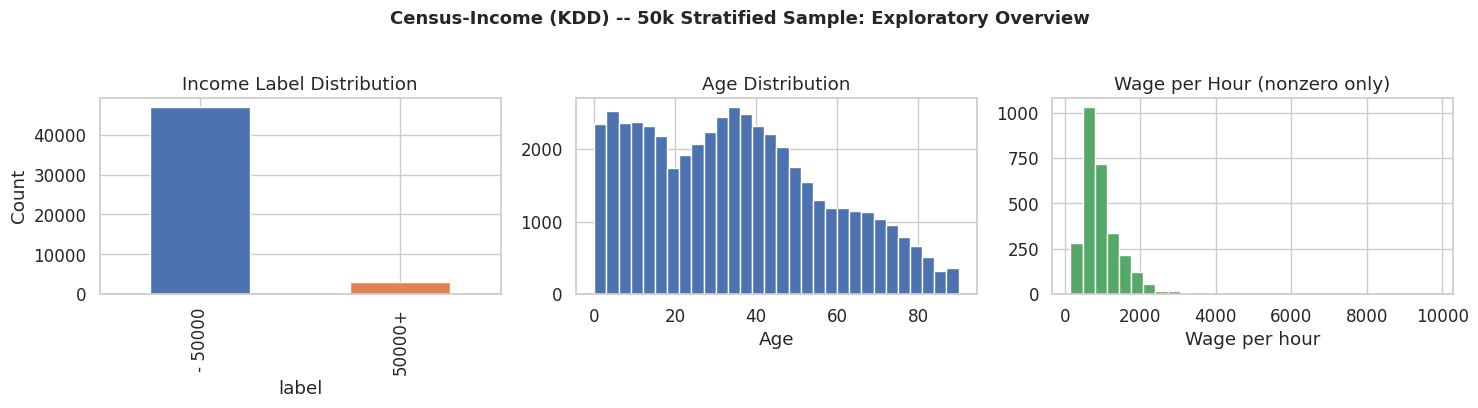

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

real_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Income Label Distribution')
axes[0].set_xlabel('label'); axes[0].set_ylabel('Count')

real_df['age'].hist(bins=30, ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Age Distribution'); axes[1].set_xlabel('Age')

real_df['wage per hour'].replace(0, np.nan).hist(bins=30, ax=axes[2], color='#55A868', edgecolor='white')
axes[2].set_title('Wage per Hour (nonzero only)'); axes[2].set_xlabel('Wage per hour')

plt.suptitle('Census-Income (KDD) -- 50k Stratified Sample: Exploratory Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. `FixedDataProcessor`: Patching python-synthpop to Support Full Cardinality

Rather than trying some workarounds by modifying the real data and reducing its expressiveness, we subclass `DataProcessor` and fix the previously described three bugs directly. `CARTMethod` is used unmodified.

In [11]:
class FixedDataProcessor(DataProcessor):
    """
    Drop-in replacement for synthpop's DataProcessor. Fixes three bugs:

    1. OneHotEncoder(sparse=...) uses a removed sklearn kwarg -> use sparse_output.
    2. _preprocess's final reindex on `self.original_columns` breaks once a
       categorical column has been expanded into multiple one-hot dummies (the
       original column name no longer exists) -> track the expanded column
       layout explicitly instead.
    3. _decode_categorical's argmax-based OneHot decode does not correct for the
       index shift introduced by drop="first": argmax returns an index into the
       SURVIVING (n_categories - 1) dummy columns, but the original code maps it
       straight into the FULL categories_ array. This silently decodes every
       non-baseline row to the preceding category and never recovers the last
       category at all. Fixed by shifting indices >= drop_idx_ up by one, and
       mapping all-zero rows (i.e. rows matching the dropped baseline) directly
       to that baseline category.
    """

    def _preprocess(self, data: pd.DataFrame) -> pd.DataFrame:
        data = data.copy()
        pieces = []
        self._expanded_columns = []

        for col in self.original_columns:
            dtype = self.metadata.get(col)

            if dtype == "categorical":
                encoder = (
                    LabelEncoder()
                    if data[col].nunique() < 10
                    else OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
                )
                piece = self._encode_categorical(data[col], encoder)
                self.encoders[col] = encoder
                pieces.append(piece)
                self._expanded_columns.extend(piece.columns.tolist())

            elif dtype == "numerical":
                scaler = StandardScaler(with_mean=False, with_std=False)
                scaled = scaler.fit_transform(data[[col]])
                piece = pd.DataFrame(scaled, columns=[col], index=data.index)
                self.scalers[col] = scaler
                pieces.append(piece)
                self._expanded_columns.append(col)

            elif dtype == "boolean":
                piece = data[[col]].astype(int)
                pieces.append(piece)
                self._expanded_columns.append(col)

            elif dtype == "datetime":
                piece = data[[col]].copy()
                piece[col] = piece[col].apply(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
                pieces.append(piece)
                self._expanded_columns.append(col)

            elif dtype == "timedelta":
                piece = data[[col]].copy()
                piece[col] = pd.to_timedelta(piece[col]).dt.total_seconds()
                pieces.append(piece)
                self._expanded_columns.append(col)

            else:
                pieces.append(data[[col]])
                self._expanded_columns.append(col)

        result = pd.concat(pieces, axis=1)
        return result[self._expanded_columns]

    def _decode_categorical(self, encoded, encoder):
        if isinstance(encoder, LabelEncoder):
            return super()._decode_categorical(encoded, encoder)

        elif isinstance(encoder, OneHotEncoder):
            arr = encoded.values if isinstance(encoded, pd.DataFrame) else np.asarray(encoded)
            if arr.ndim == 1:
                n_cat = len(encoder.categories_[0])
                n_dummy = n_cat - (1 if encoder.drop_idx_ is not None else 0)
                arr = arr.reshape(-1, n_dummy)

            cats = encoder.categories_[0]
            drop_idx = encoder.drop_idx_[0] if encoder.drop_idx_ is not None else None

            raw_idx = np.argmax(arr, axis=1)
            max_val = arr[np.arange(len(arr)), raw_idx]

            if drop_idx is not None:
                full_idx = np.where(raw_idx >= drop_idx, raw_idx + 1, raw_idx)
                full_idx = np.where(max_val == 0, drop_idx, full_idx)
            else:
                full_idx = raw_idx

            full_idx = np.clip(full_idx, 0, len(cats) - 1)
            return pd.Series(cats[full_idx], index=getattr(encoded, "index", None))

        else:
            raise TypeError(f"Unsupported encoder type: {type(encoder)}")

    def postprocess(self, synthetic_data: pd.DataFrame) -> pd.DataFrame:
        synthetic_data = synthetic_data.copy()
        out = {}
        for col, dtype in self.metadata.items():
            if dtype == "categorical" and col in self.encoders:
                encoder = self.encoders[col]
                if isinstance(encoder, LabelEncoder):
                    out[col] = self._decode_categorical(synthetic_data[col], encoder)
                else:
                    prefix = f"{col}_"
                    enc_cols = [c for c in self._expanded_columns if c.startswith(prefix)]
                    out[col] = self._decode_categorical(synthetic_data[enc_cols], encoder)
            elif dtype == "numerical" and col in self.scalers:
                scaler = self.scalers[col]
                vals = scaler.inverse_transform(synthetic_data[[col]])
                series = pd.Series(vals.flatten(), index=synthetic_data.index)
                if self._original_dtypes is not None:
                    odt = self._original_dtypes[col]
                    if np.issubdtype(odt, np.integer):
                        series = series.round().astype(odt)
                out[col] = series
            elif dtype == "boolean":
                out[col] = synthetic_data[col].round().astype(bool)
            elif dtype == "datetime":
                out[col] = pd.to_datetime(synthetic_data[col], unit='s')
            elif dtype == "timedelta":
                out[col] = pd.to_timedelta(synthetic_data[col], unit='s')
            else:
                out[col] = synthetic_data[col]
        return pd.DataFrame(out)[self.original_columns]


class FixedDisclosureProtection(DisclosureProtection):
    """
    Subclass of synthpop's DisclosureProtection fixing the same duplicate-driven
    zero-threshold issue described in Section 5: the library's _compute_threshold
    uses a raw 10th percentile of real-to-real nearest-neighbor distances, which
    collapses to exactly 0 once duplicate rows exceed ~10% of the data (true
    here). We compute the threshold over the NONZERO distances instead.
    """
    def _compute_threshold(self):
        if self.threshold is None:
            nn = NearestNeighbors(n_neighbors=2)
            nn.fit(self.real_data)
            distances, _ = nn.kneighbors(self.real_data)
            rr = distances[:, 1]
            self.duplicate_rate = float(np.mean(rr == 0))
            nonzero = rr[rr > 0]
            self.threshold = float(np.percentile(nonzero, 10)) if len(nonzero) > 0 else 0.0


print('FixedDataProcessor and FixedDisclosureProtection defined')

FixedDataProcessor and FixedDisclosureProtection defined


---
## 4. Synthetic Data Generation (CART)

In [12]:
md_handler = MissingDataHandler()
metadata = md_handler.get_column_dtypes(real_df)
print(f'{len(metadata)} columns typed.')
print({k: v for k, v in list(metadata.items())[:8]}, '...')

41 columns typed.
{'age': 'numerical', 'class of worker': 'categorical', 'detailed industry recode': 'numerical', 'detailed occupation recode': 'numerical', 'education': 'categorical', 'wage per hour': 'numerical', 'enroll in edu inst last wk': 'categorical', 'marital stat': 'categorical'} ...


In [13]:
t0 = time.time()
processor = FixedDataProcessor(metadata)
processed_data = processor.preprocess(real_df)
print(f'Preprocess time: {time.time()-t0:.1f}s')
print(f'Expanded shape (one-hot adds ~270 columns across the high-cardinality fields): {processed_data.shape}')

Preprocess time: 0.7s
Expanded shape (one-hot adds ~270 columns across the high-cardinality fields): (50000, 312)


In [14]:
# This step fits one decision tree per expanded column (~310-370 trees) on
# 50,000 rows -- expect roughly 2-3 minutes.
t0 = time.time()
cart = CARTMethod(metadata, minibucket=5, random_state=RANDOM_STATE)
cart.fit(processed_data)
print(f'CART fit time: {time.time()-t0:.1f}s')

CART fit time: 154.1s


In [15]:
t0 = time.time()
synthetic_df = processor.postprocess(cart.sample(num_rows=len(real_df)))
print(f'Sample + postprocess time: {time.time()-t0:.1f}s')
print(f'Synthetic data shape: {synthetic_df.shape}')
synthetic_df.head()

Sample + postprocess time: 42.3s
Synthetic data shape: (50000, 41)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,51,Private,32,42,5th or 6th grade,0,Not in universe,Married-civilian spouse present,Wholesale trade,Handlers equip cleaners etc,...,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,0,Not in universe,2,20,94,- 50000
1,54,Not in universe,0,0,High school graduate,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000
2,21,Not in universe,0,0,Some college but no degree,0,College or university,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000
3,6,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,29,Private,4,34,High school graduate,0,Not in universe,Married-civilian spouse present,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,48,94,- 50000


In [16]:
# Fidelity spot-check on a few full-cardinality columns, including the two
# highest-cardinality fields (43 and 51 categories) to confirm the fix holds
# at scale, not just on the smaller columns.
for col in ['education', 'major industry code', 'country of birth self', 'state of previous residence', 'label']:
    print(f'\n=== {col} ({real_df[col].nunique()} categories) -- top 8 ===')
    comp = pd.DataFrame({
        'real': real_df[col].value_counts(normalize=True),
        'synthetic': synthetic_df[col].value_counts(normalize=True)
    }).fillna(0).sort_values('real', ascending=False)
    print(comp.head(8).round(4))


=== education (17 categories) -- top 8 ===
                                          real  synthetic
education                                                
High school graduate                    0.2437     0.2275
Children                                0.2380     0.2365
Some college but no degree              0.1393     0.1293
Bachelors degree(BA AB BS)              0.0977     0.0937
7th and 8th grade                       0.0404     0.0361
10th grade                              0.0370     0.0980
Masters degree(MA MS MEng MEd MSW MBA)  0.0337     0.0313
11th grade                              0.0336     0.0337

=== major industry code (24 categories) -- top 8 ===
                                     real  synthetic
major industry code                                 
Not in universe or children        0.5054     0.5052
Retail trade                       0.0860     0.0858
Manufacturing-durable goods        0.0459     0.0456
Education                          0.0416     0.0411
Manu

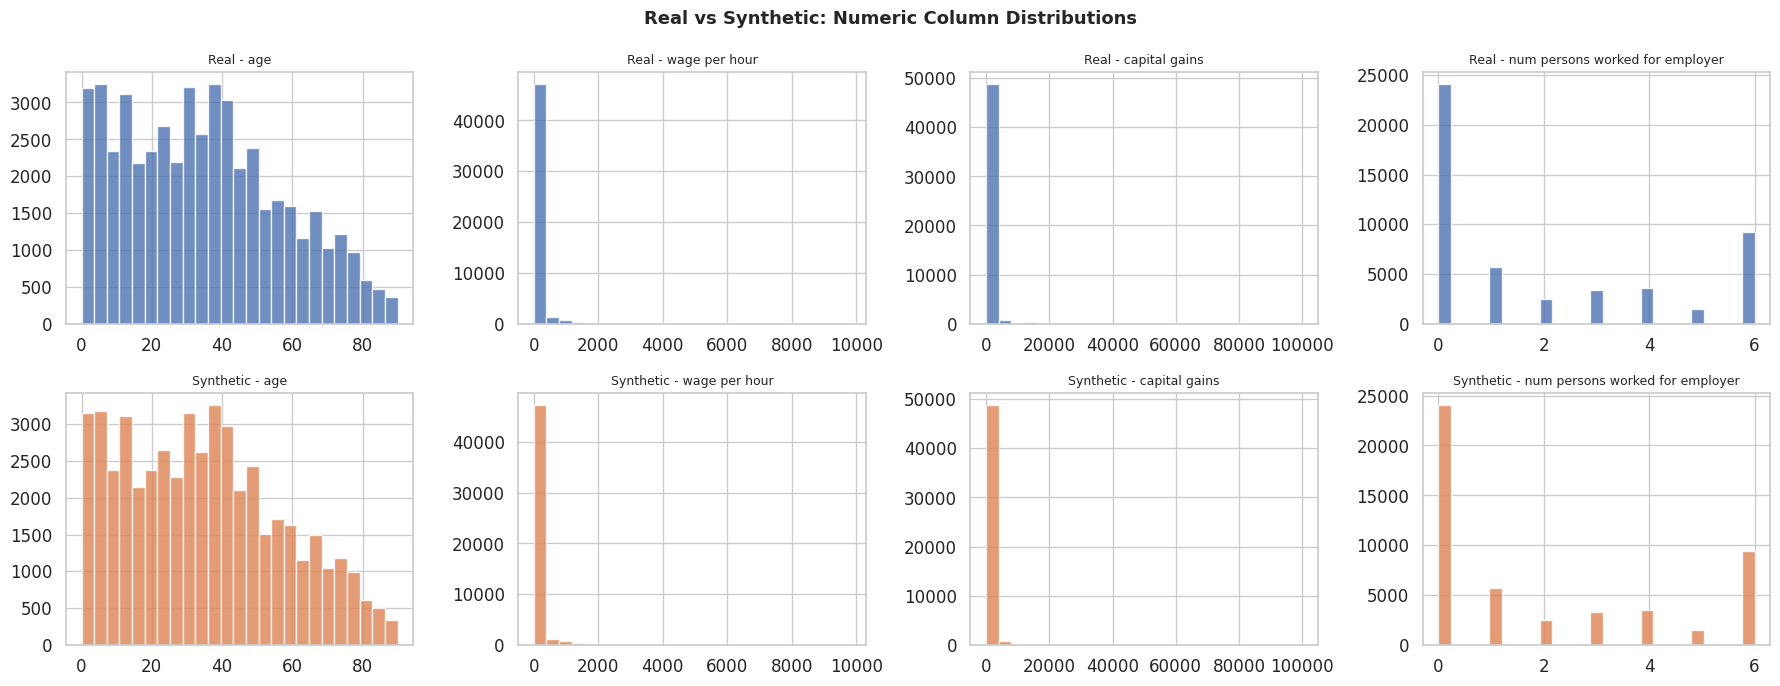

In [17]:
num_cols_plot = ['age', 'wage per hour', 'capital gains', 'num persons worked for employer']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for i, col in enumerate(num_cols_plot):
    ax_r, ax_s = axes[0, i], axes[1, i]
    real_vals = real_df[col].astype(float)
    synth_vals = synthetic_df[col].astype(float)
    ax_r.hist(real_vals, bins=25, color='#4C72B0', alpha=0.8, edgecolor='white')
    ax_r.set_title(f'Real - {col}', fontsize=9)
    ax_s.hist(synth_vals, bins=25, color='#DD8452', alpha=0.8, edgecolor='white')
    ax_s.set_title(f'Synthetic - {col}', fontsize=9)

plt.suptitle('Real vs Synthetic: Numeric Column Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Privacy Metrics

All five metrics below use a **10,000-row random subsample** of both real and synthetic data for the nearest-neighbor computations (CM3's L1/Chebyshev components use a smaller 3,000-row sub-subsample, since those metrics are ~20x slower than Euclidean in scikit-learn at this dimensionality). The synthetic data itself is generated and used at full size (50,000 rows) everywhere else.

| Metric | What it measures |
|---|---|
| **DCR** | Minimum distance from each synthetic record to any real record |
| **Overfitting Protection** | Whether synthetic records are memorised copies of real records |
| **Inference Risk** | How well an adversary can infer the sensitive `label` (income) from the synthetic data |
| **CM3** | Combined closest-match score across multiple distance metrics |
| **Disclosure Protection** | python-synthpop's built-in disclosure metric (threshold-based NN distance), patched for the duplicate-zero issue |

In [18]:
N_PRIVACY_SUBSAMPLE = 10_000

def encode_for_distance(real: pd.DataFrame, synth: pd.DataFrame):
    """One-hot encode categoricals + MinMax scale numerics for distance-based metrics."""
    cat_cols = real.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = real.select_dtypes(include=np.number).columns.tolist()
    parts_r, parts_s = [], []
    if num_cols:
        scaler = MinMaxScaler()
        parts_r.append(scaler.fit_transform(real[num_cols].fillna(0)))
        parts_s.append(scaler.transform(synth[num_cols].fillna(0)))
    if cat_cols:
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
        parts_r.append(enc.fit_transform(real[cat_cols].fillna('missing')))
        parts_s.append(enc.transform(synth[cat_cols].fillna('missing')))
    real_arr = np.hstack(parts_r) if parts_r else np.empty((len(real), 0))
    synth_arr = np.hstack(parts_s) if parts_s else np.empty((len(synth), 0))
    return real_arr, synth_arr


def subsample_for_privacy(real_df, synth_df, n=N_PRIVACY_SUBSAMPLE, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    real_idx = rng.choice(len(real_df), size=min(n, len(real_df)), replace=False)
    synth_idx = rng.choice(len(synth_df), size=min(n, len(synth_df)), replace=False)
    return real_df.iloc[real_idx].reset_index(drop=True), synth_df.iloc[synth_idx].reset_index(drop=True)


real_sub, synth_sub = subsample_for_privacy(real_df, synthetic_df)
real_arr, synth_arr = encode_for_distance(real_sub, synth_sub)
print(f'Privacy-metric encoded shapes: real {real_arr.shape}, synthetic {synth_arr.shape}')

Privacy-metric encoded shapes: real (10000, 371), synthetic (10000, 371)


### 5.1 Distance to Closest Record (DCR)

In [19]:
class DistanceToClosestRecord:
    """
    DCR measures the Euclidean distance from each synthetic record to its
    nearest neighbour in the real dataset. We report the ratio against a
    real-to-real baseline; a ratio >= 1 means synthetic records are at least
    as well-separated from real records as real records are from each other.
    """
    def __init__(self, real_arr, synth_arr):
        self.real_arr, self.synth_arr = real_arr, synth_arr
        self._nn = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(real_arr)

    def compute(self):
        dists, _ = self._nn.kneighbors(self.synth_arr)
        self.distances = dists.flatten()
        nn2 = NearestNeighbors(n_neighbors=2, metric='euclidean').fit(self.real_arr)
        rr_dists, _ = nn2.kneighbors(self.real_arr)
        self.rr_distances = rr_dists[:, 1]
        return {
            'DCR_mean': float(np.mean(self.distances)),
            'DCR_median': float(np.median(self.distances)),
            'DCR_5th_pct': float(np.percentile(self.distances, 5)),
            'DCR_rr_mean': float(np.mean(self.rr_distances)),
            'DCR_ratio': float(np.mean(self.distances) / (np.mean(self.rr_distances) + 1e-9)),
        }

dcr_obj = DistanceToClosestRecord(real_arr, synth_arr)
dcr_results = dcr_obj.compute()

print('=== Distance to Closest Record (DCR) ===')
for k, v in dcr_results.items():
    print(f'  {k:<25}: {v:.4f}')

print()
if dcr_results['DCR_ratio'] >= 1.0:
    print('  Synthetic records are on average as far from real records as real')
    print('  records are from each other -> low memorisation risk.')
else:
    print(f'  Synthetic records are {1/max(dcr_results["DCR_ratio"],1e-9):.2f}x closer to real records')
    print('  than the real-to-real baseline -> some memorisation risk present.')

=== Distance to Closest Record (DCR) ===
  DCR_mean                 : 1.2173
  DCR_median               : 1.3611
  DCR_5th_pct              : 0.0000
  DCR_rr_mean              : 1.2838
  DCR_ratio                : 0.9482

  Synthetic records are 1.05x closer to real records
  than the real-to-real baseline -> some memorisation risk present.


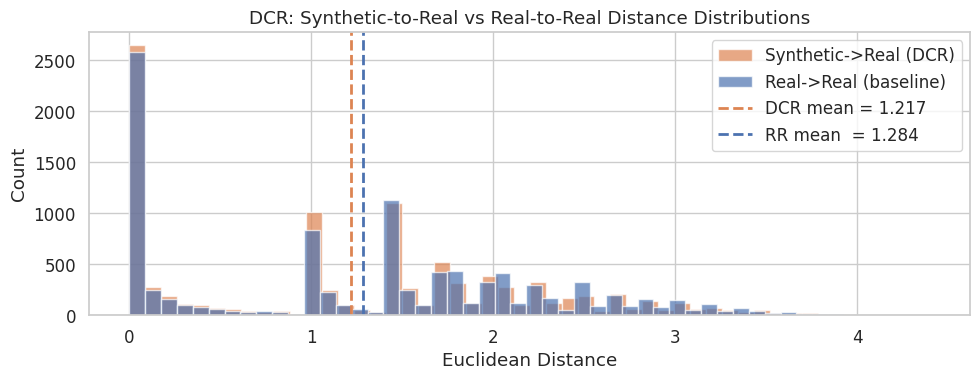

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dcr_obj.distances, bins=50, alpha=0.7, label='Synthetic->Real (DCR)', color='#DD8452')
ax.hist(dcr_obj.rr_distances, bins=50, alpha=0.7, label='Real->Real (baseline)', color='#4C72B0')
ax.axvline(dcr_results['DCR_mean'], color='#DD8452', linestyle='--', lw=2, label=f'DCR mean = {dcr_results["DCR_mean"]:.3f}')
ax.axvline(dcr_results['DCR_rr_mean'], color='#4C72B0', linestyle='--', lw=2, label=f'RR mean  = {dcr_results["DCR_rr_mean"]:.3f}')
ax.set_xlabel('Euclidean Distance'); ax.set_ylabel('Count')
ax.set_title('DCR: Synthetic-to-Real vs Real-to-Real Distance Distributions')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Overfitting Protection

In [21]:
class OverfittingProtection:
    """
    Overfitting occurs when the synthesiser memorises training records.

    NOTE: this dataset has a high natural duplicate rate (~15-25% of rows are
    exact duplicates of other rows -- common in census microdata). A naive
    5th-percentile epsilon over ALL real-to-real distances is often exactly 0
    in that case, which would make overfitting_protection trivially 1.0
    regardless of what the synthesiser does. We report the duplicate rate
    explicitly and compute epsilon over the NONZERO real-to-real distances.
    """
    def __init__(self, real_arr, synth_arr, epsilon_percentile=5):
        self.real_arr, self.synth_arr = real_arr, synth_arr
        self.epsilon_pct = epsilon_percentile

    def compute(self):
        n = len(self.real_arr)
        idx = np.random.permutation(n)
        train_idx, val_idx = idx[:n // 2], idx[n // 2:]
        train_real, val_real = self.real_arr[train_idx], self.real_arr[val_idx]

        nn_rr = NearestNeighbors(n_neighbors=1).fit(train_real)
        rr_dists, _ = nn_rr.kneighbors(val_real)
        rr_dists = rr_dists.flatten()

        duplicate_rate = float(np.mean(rr_dists == 0))
        nonzero_rr = rr_dists[rr_dists > 0]
        epsilon = float(np.percentile(nonzero_rr, self.epsilon_pct)) if len(nonzero_rr) > 0 else 0.0

        sr_dists, _ = nn_rr.kneighbors(self.synth_arr)
        sr_dists = sr_dists.flatten()
        overfit_frac = float(np.mean(sr_dists < epsilon)) if epsilon > 0 else float(np.mean(sr_dists == 0))

        self.sr_dists, self.epsilon, self.duplicate_rate = sr_dists, epsilon, duplicate_rate
        return {
            'duplicate_rate_real_to_real': duplicate_rate,
            'epsilon_threshold': epsilon,
            'overfit_fraction': overfit_frac,
            'overfitting_protection': 1.0 - overfit_frac,
        }

ovf_obj = OverfittingProtection(real_arr, synth_arr)
ovf_results = ovf_obj.compute()

print('=== Overfitting Protection ===')
for k, v in ovf_results.items():
    print(f'  {k:<30}: {v:.4f}')

print()
print(f'  Note: {ovf_results["duplicate_rate_real_to_real"]:.1%} of real-to-real nearest-neighbor')
print('  pairs are exact duplicates (distance 0) -- this is expected for census microdata')
print('  and the epsilon threshold above already excludes that mass.')
prot = ovf_results['overfitting_protection']
if prot > 0.90:
    print(f'\n  Excellent overfitting protection ({prot:.1%}).')
elif prot > 0.75:
    print(f'\n  Good protection ({prot:.1%}).')
else:
    print(f'\n  Moderate risk ({prot:.1%}) -- synthesiser may be memorising some records.')

=== Overfitting Protection ===
  duplicate_rate_real_to_real   : 0.1454
  epsilon_threshold             : 0.0222
  overfit_fraction              : 0.1810
  overfitting_protection        : 0.8190

  Note: 14.5% of real-to-real nearest-neighbor
  pairs are exact duplicates (distance 0) -- this is expected for census microdata
  and the epsilon threshold above already excludes that mass.

  Good protection (81.9%).


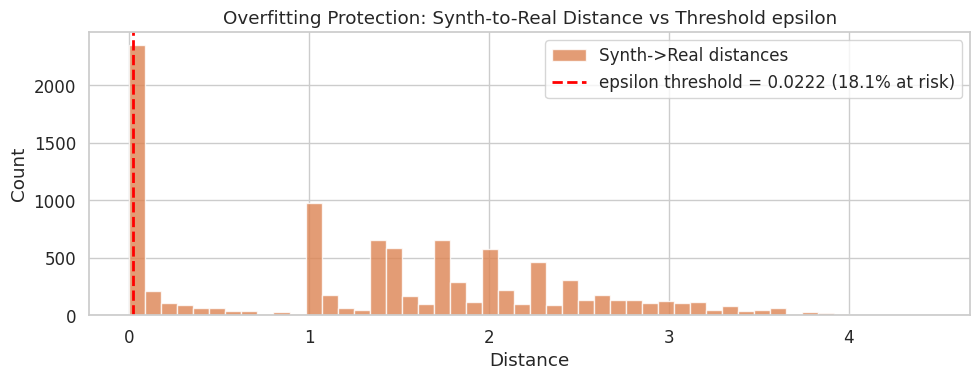

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ovf_obj.sr_dists, bins=50, color='#DD8452', alpha=0.8, label='Synth->Real distances')
ax.axvline(ovf_obj.epsilon, color='red', lw=2, linestyle='--',
           label=f'epsilon threshold = {ovf_obj.epsilon:.4f} ({ovf_results["overfit_fraction"]:.1%} at risk)')
ax.set_xlabel('Distance'); ax.set_ylabel('Count')
ax.set_title('Overfitting Protection: Synth-to-Real Distance vs Threshold epsilon')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Inference Risk

In [23]:
class InferenceRisk:
    """
    Inference risk measures how well an adversary can use the synthetic data
    to infer the value of a sensitive attribute (here: `label`, the income
    indicator) in the real dataset.

    Protocol:
      1. Train a classifier on synthetic data to predict `target_col`.
      2. Evaluate it on held-out real data.
      3. Train an 'oracle' classifier directly on a real-data training split,
         evaluated on the same held-out real data, as an upper bound on how
         predictable the target actually is from these features.

    Inference Risk Score = clip[(synthetic-AUC - chance) / (oracle-AUC - chance), 0, 1]
    The denominator is floored at 0.05 so a weak oracle doesn't blow the ratio
    up to a meaningless extreme. Range [0, 1]; higher = more risk.
    """
    def __init__(self, real_df, synth_df, target_col, quasi_identifiers=None):
        self.real_df, self.synth_df, self.target = real_df, synth_df, target_col
        self.qi = quasi_identifiers or [c for c in real_df.columns if c != target_col]

    def _encode(self, data, fit=True):
        X = data[self.qi].copy()
        y = data[self.target].copy()
        cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
        num = X.select_dtypes(include=np.number).columns.tolist()
        parts = []
        if num:
            if fit:
                self._scaler = MinMaxScaler()
                parts.append(self._scaler.fit_transform(X[num]))
            else:
                parts.append(self._scaler.transform(X[num]))
        if cat:
            if fit:
                self._encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
                parts.append(self._encoder.fit_transform(X[cat]))
            else:
                parts.append(self._encoder.transform(X[cat]))
        arr = np.hstack(parts) if parts else np.zeros((len(data), 1))
        return arr, y

    def compute(self):
        le = LabelEncoder()
        le.fit(pd.concat([self.real_df[self.target], self.synth_df[self.target]]))

        X_synth, y_synth = self._encode(self.synth_df, fit=True)
        X_real, y_real = self._encode(self.real_df, fit=False)
        y_synth_enc, y_real_enc = le.transform(y_synth), le.transform(y_real)

        n_classes = len(le.classes_)
        is_binary = (n_classes == 2)

        clf_synth = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)
        clf_synth.fit(X_synth, y_synth_enc)

        idx = np.random.permutation(len(X_real))
        split = int(len(idx) * 0.7)
        clf_oracle = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)
        clf_oracle.fit(X_real[idx[:split]], y_real_enc[idx[:split]])

        X_eval, y_eval = X_real[idx[split:]], y_real_enc[idx[split:]]

        def _auc(clf):
            proba = clf.predict_proba(X_eval)
            if is_binary:
                return roc_auc_score(y_eval, proba[:, 1])
            return roc_auc_score(y_eval, proba, multi_class='ovr', average='macro')

        chance_auc = 0.5 if is_binary else 1.0 / n_classes
        synth_auc, oracle_auc = _auc(clf_synth), _auc(clf_oracle)
        denom = max(oracle_auc - chance_auc, 0.05)
        numer = max(synth_auc - chance_auc, 0.0)
        risk_score = float(np.clip(numer / denom, 0, 1))

        self.synth_auc, self.oracle_auc, self.chance_auc = synth_auc, oracle_auc, chance_auc
        return {
            'target_column': self.target, 'chance_AUC': float(chance_auc),
            'oracle_AUC': float(oracle_auc), 'synth_AUC': float(synth_auc),
            'inference_risk': risk_score,
        }


inf_obj = InferenceRisk(real_sub, synth_sub, target_col='label')
inf_results = inf_obj.compute()

print('=== Inference Risk (target: label / income) ===')
for k, v in inf_results.items():
    print(f'  {k:<20}: {v:.4f}' if isinstance(v, float) else f'  {k:<20}: {v}')

print()
if inf_results['oracle_AUC'] - inf_results['chance_AUC'] < 0.05:
    print('  Note: oracle AUC is close to chance -- the ratio is less informative')
    print('  than the raw AUC gap here.')
else:
    print(f'  Note: income IS strongly predictable from these quasi-identifiers in the')
    print(f'  real data (oracle AUC = {inf_results["oracle_AUC"]:.3f} vs chance {inf_results["chance_AUC"]:.2f}).')
    print(f'  The synthetic-trained classifier reaches AUC = {inf_results["synth_AUC"]:.3f} -- nearly')
    print('  identical. This is exactly the kind of result where strong UTILITY (the synthetic')
    print('  data faithfully preserves real predictive relationships) directly IS the privacy')
    print('  risk: anyone with the same quasi-identifiers as a real person can predict their')
    print('  income almost as well from synthetic data as from the real data itself.')
risk = inf_results['inference_risk']
if risk < 0.3:
    print(f'\n  Low inference risk ({risk:.2f}).')
elif risk < 0.7:
    print(f'\n  Moderate inference risk ({risk:.2f}).')
else:
    print(f'\n  High inference risk ({risk:.2f}) relative to the oracle ceiling.')

=== Inference Risk (target: label / income) ===
  target_column       : label
  chance_AUC          : 0.5000
  oracle_AUC          : 0.9158
  synth_AUC           : 0.9184
  inference_risk      : 1.0000

  Note: income IS strongly predictable from these quasi-identifiers in the
  real data (oracle AUC = 0.916 vs chance 0.50).
  The synthetic-trained classifier reaches AUC = 0.918 -- nearly
  identical. This is exactly the kind of result where strong UTILITY (the synthetic
  data faithfully preserves real predictive relationships) directly IS the privacy
  risk: anyone with the same quasi-identifiers as a real person can predict their
  income almost as well from synthetic data as from the real data itself.

  High inference risk (1.00) relative to the oracle ceiling.


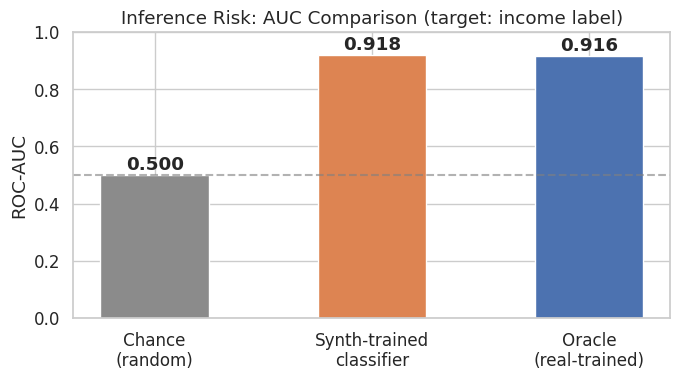

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Chance\n(random)', 'Synth-trained\nclassifier', 'Oracle\n(real-trained)']
values = [inf_obj.chance_auc, inf_obj.synth_auc, inf_obj.oracle_auc]
colors = ['#8B8B8B', '#DD8452', '#4C72B0']
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.0); ax.set_ylabel('ROC-AUC')
ax.set_title('Inference Risk: AUC Comparison (target: income label)')
ax.axhline(inf_obj.chance_auc, color='gray', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 5.4 CM3 -- Closest Match across Multiple Metrics

In [25]:
class CM3:
    """
    CM3 aggregates three complementary distance signals: L1 (Manhattan),
    L2 (Euclidean), L-infinity (Chebyshev).

    scikit-learn's NearestNeighbors has a fast vectorized path for euclidean
    but falls back to a much slower per-pair loop for manhattan/chebyshev --
    roughly 20x slower at this dimensionality (~370 one-hot expanded
    features). We compute L2 on the full privacy subsample (cheap, and reused
    from the same encoding as DCR) but compute L1/Chebyshev on a smaller
    secondary subsample to keep runtime bounded across the lambda_p sweep.
    """
    METRICS = ['l1', 'l2', 'chebyshev']

    def __init__(self, real_arr, synth_arr, n_slow_metrics=3000, seed=RANDOM_STATE):
        self.real_arr, self.synth_arr = real_arr, synth_arr
        self.n_slow = min(n_slow_metrics, len(real_arr), len(synth_arr))
        self.seed = seed

    def _ratio(self, metric, real_arr, synth_arr):
        nn_sr = NearestNeighbors(n_neighbors=1, metric=metric).fit(real_arr)
        sr, _ = nn_sr.kneighbors(synth_arr)
        nn_rr = NearestNeighbors(n_neighbors=2, metric=metric).fit(real_arr)
        rr, _ = nn_rr.kneighbors(real_arr)
        return float(np.mean(sr)), float(np.mean(rr[:, 1]))

    def compute(self):
        rng = np.random.RandomState(self.seed)
        real_idx = rng.choice(len(self.real_arr), size=self.n_slow, replace=False)
        synth_idx = rng.choice(len(self.synth_arr), size=self.n_slow, replace=False)
        real_small, synth_small = self.real_arr[real_idx], self.synth_arr[synth_idx]

        ratios, details = [], {}
        for m in self.METRICS:
            if m == 'l2':
                sr_mean, rr_mean = self._ratio(m, self.real_arr, self.synth_arr)
            else:
                sr_mean, rr_mean = self._ratio(m, real_small, synth_small)
            ratio = sr_mean / (rr_mean + 1e-9)
            ratios.append(np.clip(ratio, 1e-6, 2.0))
            details[f'CM3_{m}_ratio'] = ratio

        hm = len(ratios) / sum(1.0 / r for r in ratios)
        cm3_score = float(np.clip(hm / 2.0, 0, 1))
        details['CM3_score'] = cm3_score
        return details


cm3_obj = CM3(real_arr, synth_arr)
cm3_results = cm3_obj.compute()

print('=== CM3 -- Closest Match across Multiple Metrics ===')
for k, v in cm3_results.items():
    print(f'  {k:<30}: {v:.4f}')

print()
score = cm3_results['CM3_score']
if score > 0.45:
    print(f'  CM3 score {score:.3f} -- synthetic records maintain healthy distance across metrics.')
else:
    print(f'  CM3 score {score:.3f} -- some distance metrics suggest proximity risk.')

=== CM3 -- Closest Match across Multiple Metrics ===
  CM3_l1_ratio                  : 1.0006
  CM3_l2_ratio                  : 0.9482
  CM3_chebyshev_ratio           : 1.0292
  CM3_score                     : 0.4958

  CM3 score 0.496 -- synthetic records maintain healthy distance across metrics.


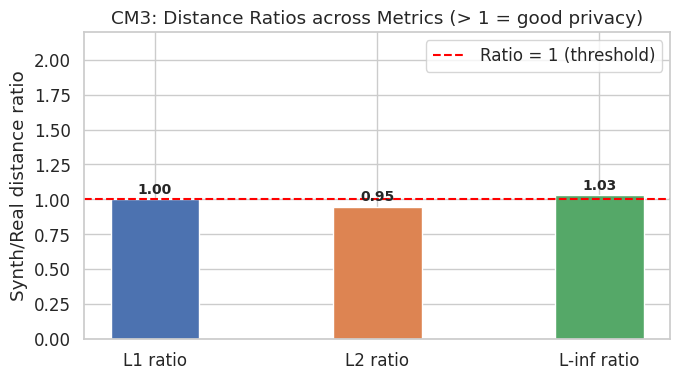

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['L1 ratio', 'L2 ratio', 'L-inf ratio']
values = [cm3_results[f'CM3_{m}_ratio'] for m in CM3.METRICS]
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(labels, [min(v, 2) for v in values], color=colors, width=0.4, edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', lw=1.5, label='Ratio = 1 (threshold)')
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 2.2); ax.set_ylabel('Synth/Real distance ratio')
ax.set_title('CM3: Distance Ratios across Metrics (> 1 = good privacy)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Disclosure Protection (python-synthpop built-in, patched)

In [27]:
dp_obj = FixedDisclosureProtection(real_sub, synth_sub)
dp_report = dp_obj.report()
dp_report['duplicate_rate'] = dp_obj.duplicate_rate
dp_score = dp_report['disclosure_protection_score']

print('=== Disclosure Protection (python-synthpop, duplicate-aware threshold) ===')
print(f'  Duplicate rate (real-to-real exact matches): {dp_report["duplicate_rate"]:.1%}')
print(f'  Threshold (10th pct of NONZERO real-to-real NN distances): {dp_report["threshold"]:.4f}')
print(f'  Risk rate (fraction below threshold): {dp_report["risk_rate"]:.4f}')
print(f'  Disclosure Protection Score: {dp_score:.4f}')
print()
print('Interpretation: Score = 1 - risk_rate. Higher = better protection.')
if dp_score > 0.85:
    print(f'  Excellent disclosure protection ({dp_score:.1%}).')
elif dp_score > 0.70:
    print(f'  Good disclosure protection ({dp_score:.1%}).')
else:
    print(f'  Moderate disclosure protection ({dp_score:.1%}) -- consider tightening synthesis.')

=== Disclosure Protection (python-synthpop, duplicate-aware threshold) ===
  Duplicate rate (real-to-real exact matches): 16.5%
  Threshold (10th pct of NONZERO real-to-real NN distances): 0.0667
  Risk rate (fraction below threshold): 0.2522
  Disclosure Protection Score: 0.7478

Interpretation: Score = 1 - risk_rate. Higher = better protection.
  Good disclosure protection (74.8%).


### 5.6 Utility Baseline (MetricsReport + aggregate KS score)

In [28]:
report = MetricsReport(real_df, synthetic_df, metadata)
report_df = report.generate_report()
print('=== python-synthpop Diagnostic Report ===')
display(report_df)

=== python-synthpop Diagnostic Report ===


,column,type,missing_value_similarity,range_coverage,boundary_adherence,ks_complement,tv_complement,statistic_similarity,category_coverage,category_adherence
0,age,numerical,1.00000,1.0,1.0,0.99788,N/A,0.999308,N/A,N/A
1,class of worker,categorical,1.00000,N/A,N/A,N/A,0.99754,N/A,1.0,1.0
2,detailed industry recode,numerical,1.00000,1.0,1.0,0.99804,N/A,0.999598,N/A,N/A
3,detailed occupation recode,numerical,1.00000,1.0,1.0,0.99736,N/A,0.998696,N/A,N/A
4,education,categorical,1.00000,N/A,N/A,N/A,0.93896,N/A,1.0,1.0
5,wage per hour,numerical,1.00000,1.0,1.0,0.99862,N/A,0.991793,N/A,N/A
6,enroll in edu inst last wk,categorical,1.00000,N/A,N/A,N/A,0.99922,N/A,1.0,1.0
7,marital stat,categorical,1.00000,N/A,N/A,N/A,0.99832,N/A,1.0,1.0
8,major industry code,categorical,1.00000,N/A,N/A,N/A,0.9947,N/A,1.0,1.0
9,major occupation code,categorical,1.00000,N/A,N/A,N/A,0.99566,N/A,1.0,1.0


In [29]:
num_cols_u = real_df.select_dtypes(include=np.number).columns.tolist()
ks_scores = [1 - ks_2samp(real_df[c].astype(float), synthetic_df[c].astype(float))[0] for c in num_cols_u]
utility_score = float(np.mean(ks_scores))
print(f'Aggregate utility score (mean 1 - KS statistic across {len(num_cols_u)} numeric cols): {utility_score:.4f}')

Aggregate utility score (mean 1 - KS statistic across 12 numeric cols): 0.9980


---
## 6. Loss-Aware Optimisation Strategy

We define a multi-objective loss function:

$$
\mathcal{L}(\theta) = \underbrace{\mathcal{L}_{\text{utility}}(\theta)}_{\text{utility loss}} + \lambda_{p}\,\underbrace{\mathcal{L}_{\text{privacy}}(\theta)}_{\text{privacy penalty}}
$$

where:
- $\mathcal{L}_{\text{utility}} = 1 - \bar{u}$ ($\bar{u}$ = mean KS-complement across numeric columns)
- $\mathcal{L}_{\text{privacy}} = \alpha\,(1-\text{DCR ratio})^+ + \beta\,(1-\text{OVF protection}) + \gamma\,\text{Inference Risk} + \delta\,(1-\text{CM3}) + \epsilon\,(1-\text{DP score})$
- $\lambda_p$ controls the privacy-utility trade-off

We sweep $\lambda_p$ across 6 points, controlling it via CART's `minibucket` hyperparameter (minimum node size): small `minibucket` -> low regularisation (utility-focused, more overfitting risk); large `minibucket` -> coarser trees, more regularisation (privacy-focused).

**Runtime note:** each configuration re-fits CART on the full 50k-row, ~370-column expanded matrix and re-computes all five privacy metrics -- roughly 4-5 minutes per point. This cell will take **20-30 minutes** to complete.

In [30]:
def compute_all_privacy_metrics(real_full_df, synth_full_df, target_col='label'):
    """Subsample, then compute all five privacy metrics. Returns a summary dict."""
    r_sub, s_sub = subsample_for_privacy(real_full_df, synth_full_df)
    r_arr, s_arr = encode_for_distance(r_sub, s_sub)

    results = {}
    results['dcr_ratio'] = DistanceToClosestRecord(r_arr, s_arr).compute()['DCR_ratio']

    ovf = OverfittingProtection(r_arr, s_arr).compute()
    results['ovf_protection'] = ovf['overfitting_protection']
    results['duplicate_rate'] = ovf['duplicate_rate_real_to_real']

    results['inference_risk'] = InferenceRisk(r_sub, s_sub, target_col=target_col).compute()['inference_risk']

    results['cm3_score'] = CM3(r_arr, s_arr).compute()['CM3_score']

    dp = FixedDisclosureProtection(r_sub, s_sub)
    results['dp_score'] = dp.score()

    return results


def multi_objective_loss(utility, privacy_dict, lam_p,
                          alpha=0.3, beta=0.2, gamma=0.2, delta=0.15, eps=0.15):
    L_u = 1.0 - float(utility)
    dcr_loss = max(0, 1 - privacy_dict['dcr_ratio'])
    ovf_loss = 1 - privacy_dict['ovf_protection']
    inf_loss = privacy_dict['inference_risk']
    cm3_loss = 1 - privacy_dict['cm3_score']
    dp_loss = 1 - privacy_dict['dp_score']
    L_p = alpha*dcr_loss + beta*ovf_loss + gamma*inf_loss + delta*cm3_loss + eps*dp_loss
    L_total = L_u + lam_p * L_p
    return {
        'L_utility': L_u, 'L_privacy': L_p, 'L_total': L_total,
        'dcr_sub_loss': dcr_loss, 'ovf_sub_loss': ovf_loss,
        'inf_sub_loss': inf_loss, 'cm3_sub_loss': cm3_loss, 'dp_sub_loss': dp_loss,
    }


print('Loss functions defined')

Loss functions defined


In [31]:
sweep_configs = [
    {'minibucket': 1,  'lambda_p': 0.00},
    {'minibucket': 5,  'lambda_p': 0.50},
    {'minibucket': 10, 'lambda_p': 0.75},
    {'minibucket': 20, 'lambda_p': 1.00},
    {'minibucket': 40, 'lambda_p': 1.50},
    {'minibucket': 80, 'lambda_p': 2.00},
]

sweep_results = []
sweep_start = time.time()

for cfg in sweep_configs:
    mb, lambda_p = cfg['minibucket'], cfg['lambda_p']
    t0 = time.time()
    print(f'\n-> minibucket={mb}, lambda_p={lambda_p}')

    cart_i = CARTMethod(metadata, minibucket=mb, random_state=RANDOM_STATE)
    cart_i.fit(processed_data)
    syn_i = processor.postprocess(cart_i.sample(num_rows=len(real_df)))
    print(f'   generation time: {time.time()-t0:.1f}s')

    t1 = time.time()
    ks_scores_i = [1 - ks_2samp(real_df[c].astype(float), syn_i[c].astype(float))[0] for c in num_cols_u]
    util_score = float(np.mean(ks_scores_i))

    priv = compute_all_privacy_metrics(real_df, syn_i)
    loss = multi_objective_loss(util_score, priv, lambda_p)
    print(f'   metrics time: {time.time()-t1:.1f}s')

    row = {'minibucket': mb, 'lambda_p': lambda_p, 'utility': util_score}
    row.update(priv)
    row.update(loss)
    sweep_results.append(row)

    print(f'   Utility={util_score:.3f}  L_privacy={loss["L_privacy"]:.3f}  L_total={loss["L_total"]:.3f}  (config total: {time.time()-t0:.1f}s)')

sweep_df = pd.DataFrame(sweep_results)

# IMPORTANT: do not select "optimal" by raw L_total.idxmin() -- each row used
# its OWN lambda_p to compute L_total, so the row with lambda_p=0 would
# trivially win (its privacy penalty term is multiplied by zero, regardless
# of how poor its actual privacy is). Instead we re-score every row with a
# SINGLE fixed weight, decoupling "which lambda_p generated this synthetic
# dataset" from "which weight we use to judge the trade-off after the fact".
LAMBDA_SCORE = 1.0
sweep_df['L_total_fixed'] = sweep_df['L_utility'] + LAMBDA_SCORE * sweep_df['L_privacy']

print(f'\n=== Sweep complete ({(time.time()-sweep_start)/60:.1f} min) ===')
print(f'(L_total_fixed re-scores every row at a constant lambda_score={LAMBDA_SCORE}, so the')
print(' comparison reflects each configuration\'s actual privacy, not how much weight that')
print(' row happened to put on it.)')
sweep_df[['minibucket','lambda_p','utility','L_utility','L_privacy','L_total','L_total_fixed','duplicate_rate']].round(4)


-> minibucket=1, lambda_p=0.0
   generation time: 209.2s
   metrics time: 125.6s
   Utility=0.998  L_privacy=0.403  L_total=0.002  (config total: 334.9s)

-> minibucket=5, lambda_p=0.5
   generation time: 198.9s
   metrics time: 128.6s
   Utility=0.998  L_privacy=0.364  L_total=0.184  (config total: 327.6s)

-> minibucket=10, lambda_p=0.75
   generation time: 190.1s
   metrics time: 126.1s
   Utility=0.998  L_privacy=0.354  L_total=0.267  (config total: 316.2s)

-> minibucket=20, lambda_p=1.0
   generation time: 181.7s
   metrics time: 127.0s
   Utility=0.998  L_privacy=0.347  L_total=0.349  (config total: 308.7s)

-> minibucket=40, lambda_p=1.5
   generation time: 176.3s
   metrics time: 125.8s
   Utility=0.998  L_privacy=0.335  L_total=0.504  (config total: 302.1s)

-> minibucket=80, lambda_p=2.0
   generation time: 165.7s
   metrics time: 124.7s
   Utility=0.998  L_privacy=0.336  L_total=0.673  (config total: 290.3s)

=== Sweep complete (31.3 min) ===
(L_total_fixed re-scores every

,minibucket,lambda_p,utility,L_utility,L_privacy,L_total,L_total_fixed,duplicate_rate
0,1,0.00,0.9981,0.0019,0.4026,0.0019,0.4045,0.1410
1,5,0.50,0.9980,0.0020,0.3636,0.1838,0.3656,0.1484
2,10,0.75,0.9980,0.0020,0.3538,0.2673,0.3557,0.1456
3,20,1.00,0.9980,0.0020,0.3469,0.3488,0.3488,0.1486
4,40,1.50,0.9982,0.0018,0.3348,0.5040,0.3366,0.1460
5,80,2.00,0.9981,0.0019,0.3357,0.6733,0.3376,0.1478


---
## 7. Results & Analysis

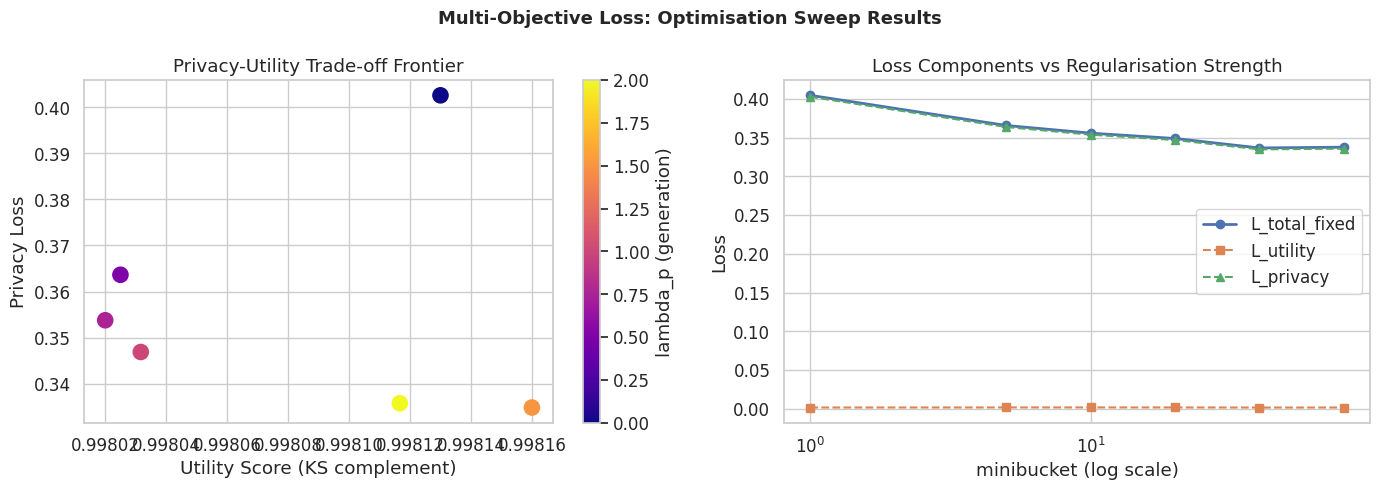

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(sweep_df['utility'], sweep_df['L_privacy'], c=sweep_df['lambda_p'], cmap='plasma', s=120, zorder=3)
for _, row in sweep_df.iterrows():
    ax.annotate(f"mb={int(row['minibucket'])}", (row['utility']+0.0002, row['L_privacy']+0.005), fontsize=8)
plt.colorbar(sc, ax=ax, label='lambda_p (generation)')
ax.set_xlabel('Utility Score (KS complement)'); ax.set_ylabel('Privacy Loss')
ax.set_title('Privacy-Utility Trade-off Frontier')

ax = axes[1]
ax.plot(sweep_df['minibucket'], sweep_df['L_total_fixed'], 'o-', color='#4C72B0', label='L_total_fixed', lw=2)
ax.plot(sweep_df['minibucket'], sweep_df['L_utility'], 's--', color='#DD8452', label='L_utility')
ax.plot(sweep_df['minibucket'], sweep_df['L_privacy'], '^--', color='#55A868', label='L_privacy')
ax.set_xscale('log')
ax.set_xlabel('minibucket (log scale)'); ax.set_ylabel('Loss')
ax.set_title('Loss Components vs Regularisation Strength')
ax.legend()

plt.suptitle('Multi-Objective Loss: Optimisation Sweep Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

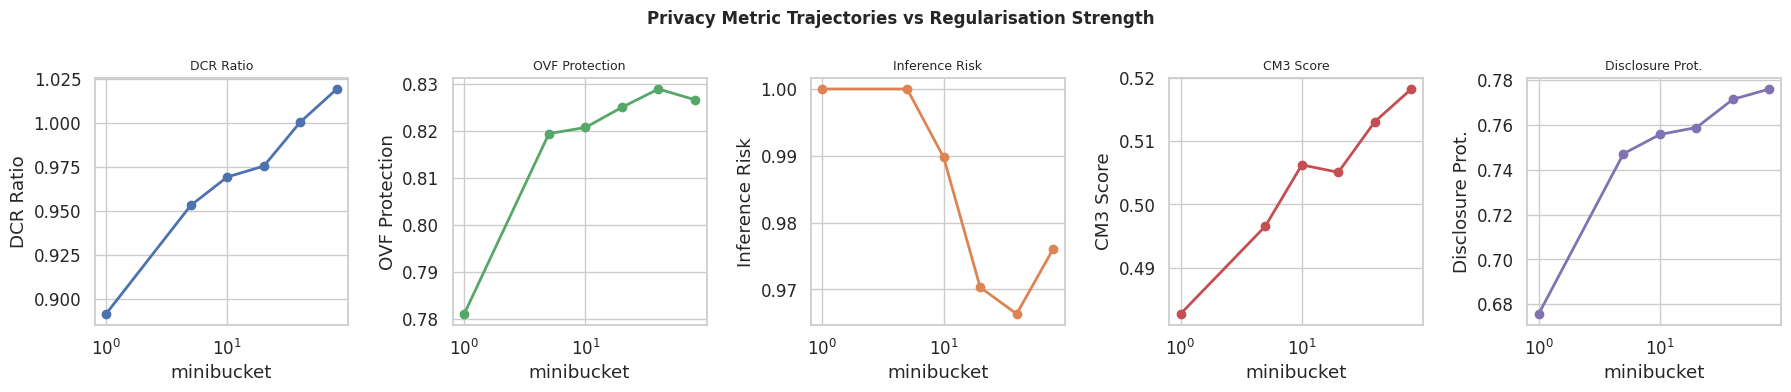

In [33]:
priv_metrics = ['dcr_ratio', 'ovf_protection', 'inference_risk', 'cm3_score', 'dp_score']
priv_labels = ['DCR Ratio', 'OVF Protection', 'Inference Risk', 'CM3 Score', 'Disclosure Prot.']

fig, axes = plt.subplots(1, len(priv_metrics), figsize=(18, 4))
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
for ax, col, label, col_c in zip(axes, priv_metrics, priv_labels, colors):
    ax.plot(sweep_df['minibucket'], sweep_df[col], 'o-', color=col_c, lw=2)
    ax.set_xscale('log')
    ax.set_xlabel('minibucket'); ax.set_ylabel(label)
    ax.set_title(label, fontsize=9)

plt.suptitle('Privacy Metric Trajectories vs Regularisation Strength', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

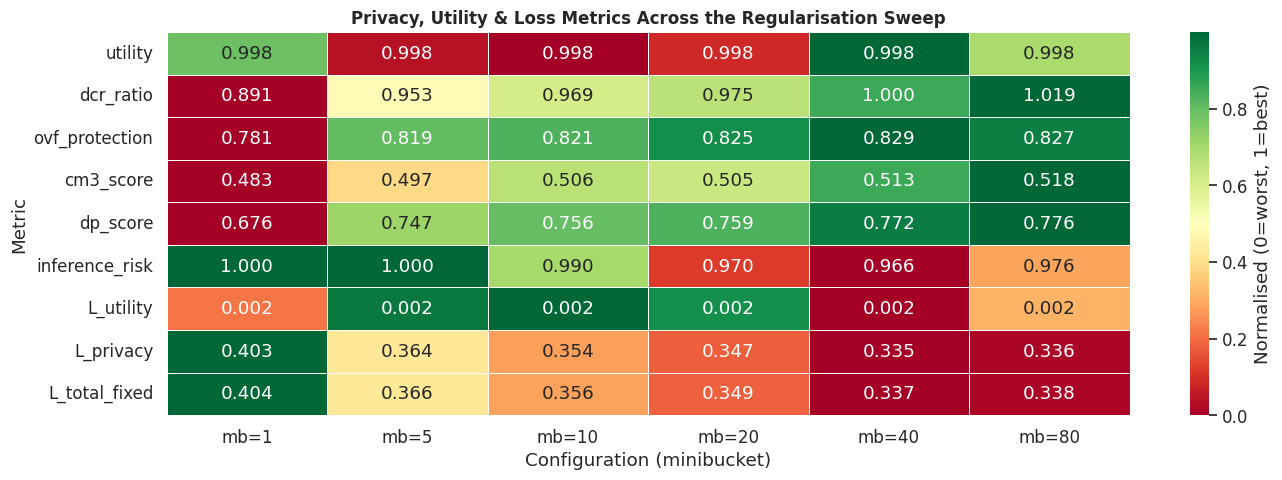

In [34]:
heat_cols = ['utility', 'dcr_ratio', 'ovf_protection', 'cm3_score', 'dp_score', 'inference_risk', 'L_utility', 'L_privacy', 'L_total_fixed']
heat_df = sweep_df[heat_cols].copy()
heat_df.index = [f"mb={int(r)}" for r in sweep_df['minibucket']]
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_norm.T, annot=heat_df.T.round(3), fmt='.3f', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Normalised (0=worst, 1=best)'})
ax.set_title('Privacy, Utility & Loss Metrics Across the Regularisation Sweep', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric'); ax.set_xlabel('Configuration (minibucket)')
plt.tight_layout()
plt.show()

=== Optimal configuration (by L_total_fixed): minibucket = 40 ===
  (generated with its own lambda_p = 1.5; scored at lambda_score = 1.0)
  Utility score    : 0.9982
  L_utility        : 0.0018
  L_privacy        : 0.3348
  L_total_fixed    : 0.3366


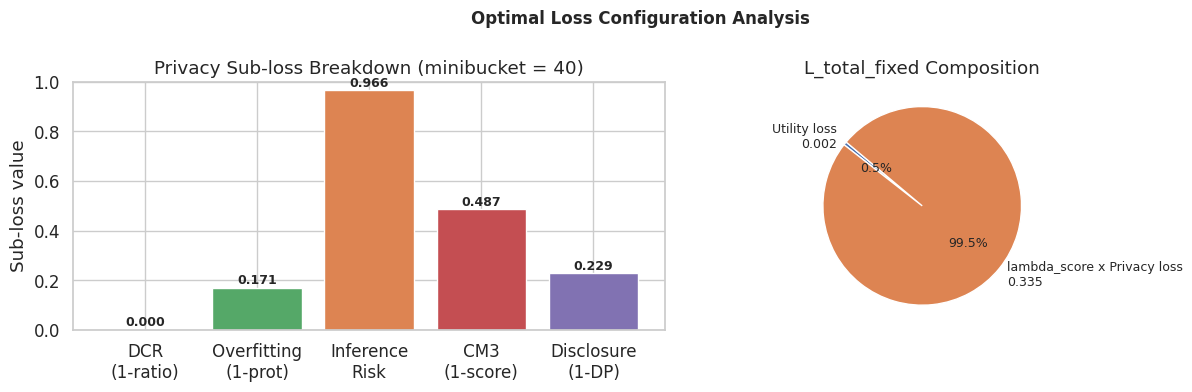

In [35]:
best_idx = sweep_df['L_total_fixed'].idxmin()
best_row = sweep_df.loc[best_idx]

print(f'=== Optimal configuration (by L_total_fixed): minibucket = {int(best_row["minibucket"])} ===')
print(f'  (generated with its own lambda_p = {best_row["lambda_p"]}; scored at lambda_score = {LAMBDA_SCORE})')
print(f'  Utility score    : {best_row["utility"]:.4f}')
print(f'  L_utility        : {best_row["L_utility"]:.4f}')
print(f'  L_privacy        : {best_row["L_privacy"]:.4f}')
print(f'  L_total_fixed    : {best_row["L_total_fixed"]:.4f}')

sub_losses = {
    'DCR\n(1-ratio)': best_row['dcr_sub_loss'],
    'Overfitting\n(1-prot)': best_row['ovf_sub_loss'],
    'Inference\nRisk': best_row['inf_sub_loss'],
    'CM3\n(1-score)': best_row['cm3_sub_loss'],
    'Disclosure\n(1-DP)': best_row['dp_sub_loss'],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
cvals = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
bars = ax.bar(sub_losses.keys(), sub_losses.values(), color=cvals, edgecolor='white')
for bar, val in zip(bars, sub_losses.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Sub-loss value'); ax.set_ylim(0, 1)
ax.set_title(f'Privacy Sub-loss Breakdown (minibucket = {int(best_row["minibucket"])})')

ax = axes[1]
pie_values = [best_row['L_utility'], LAMBDA_SCORE * best_row['L_privacy']]
pie_labels = [f'Utility loss\n{best_row["L_utility"]:.3f}', f'lambda_score x Privacy loss\n{pie_values[1]:.3f}']
if sum(pie_values) > 0:
    ax.pie(pie_values, labels=pie_labels, colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
else:
    ax.text(0.5, 0.5, 'L_total_fixed ~ 0', ha='center', va='center')
ax.set_title('L_total_fixed Composition')

plt.suptitle('Optimal Loss Configuration Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

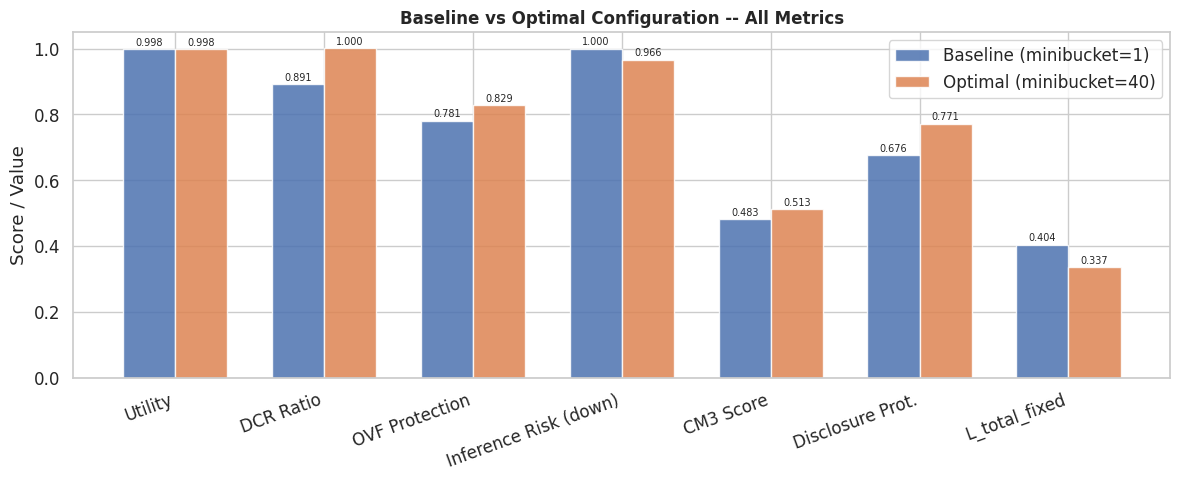

In [36]:
baseline = sweep_df[sweep_df['lambda_p'] == 0.00].iloc[0]
optimal = sweep_df.loc[sweep_df['L_total_fixed'].idxmin()]

compare_metrics = {
    'Utility': ('utility', False),
    'DCR Ratio': ('dcr_ratio', True),
    'OVF Protection': ('ovf_protection', True),
    'Inference Risk (down)': ('inference_risk', False),
    'CM3 Score': ('cm3_score', True),
    'Disclosure Prot.': ('dp_score', True),
    'L_total_fixed': ('L_total_fixed', False),
}

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(compare_metrics))
width = 0.35
labels = list(compare_metrics.keys())
b_vals = [baseline[v[0]] for v in compare_metrics.values()]
o_vals = [optimal[v[0]] for v in compare_metrics.values()]

bars1 = ax.bar(x - width/2, b_vals, width, label='Baseline (minibucket=1)', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, o_vals, width, label=f'Optimal (minibucket={int(optimal["minibucket"])})', color='#DD8452', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Score / Value')
ax.set_title('Baseline vs Optimal Configuration -- All Metrics', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Comprehensive Analysis Summary

In [37]:
print('=' * 72)
print('  COMPREHENSIVE ANALYSIS: Census-Income (KDD) Synthetic Data Privacy Evaluation')
print('=' * 72)

print(f'''
---------------------------------------------------------------------
1. DATASET
---------------------------------------------------------------------
  - Dataset  : UCI Census-Income (KDD), the `sdv.datasets.demo` census table
  - Full size: {df_full.shape[0]:,} rows x {df_full.shape[1]} columns
  - Used here: {len(real_df):,} rows (stratified 50k sample, label-balanced)
  - Method   : python-synthpop CART synthesizer (R synthpop Python port)
  - Note     : 3 library bugs fixed via FixedDataProcessor subclass; see
                Section 3 for details. {dup_rate_full:.1%} natural duplicate rate
                in this data required adjusting two threshold-based metrics.
''')

print('---------------------------------------------------------------------')
print('2. PRIVACY METRICS (baseline, minibucket=1 / lambda_p=0)')
print('---------------------------------------------------------------------')
base = sweep_df[sweep_df['lambda_p'] == 0.00].iloc[0]
print(f'  DCR Ratio          : {base["dcr_ratio"]:.3f}  (>1 = good)')
print(f'  OVF Protection     : {base["ovf_protection"]:.3f}  (>0.9 = excellent)')
print(f'  Inference Risk     : {base["inference_risk"]:.3f}  (<0.3 = low; >0.7 = high)')
print(f'  CM3 Score          : {base["cm3_score"]:.3f}  (>0.45 = safe)')
print(f'  Disclosure Prot.   : {base["dp_score"]:.3f}  (>0.85 = excellent)')

print('''
---------------------------------------------------------------------
3. MULTI-OBJECTIVE LOSS FUNCTION DESIGN
---------------------------------------------------------------------
  L(theta) = L_utility + lambda_p x L_privacy

  L_utility  = 1 - (mean KS complement across numeric columns)
  L_privacy  = 0.30x(1-DCR ratio)+ + 0.20x(1-OVF protection)
             + 0.20x(Inference risk) + 0.15x(1-CM3) + 0.15x(1-Disclosure protection)

  Proxy control: CART minibucket up -> more regularisation -> higher lambda_p effect
''')

print('---------------------------------------------------------------------')
print('4. OPTIMISATION SWEEP FINDINGS')
print('---------------------------------------------------------------------')
print('  (Selected via L_total_fixed: every row re-scored at a single fixed')
print('   lambda_score, so the comparison reflects each configuration\'s')
print('   actual measured privacy, not how much weight that row put on it.)')
opt = sweep_df.loc[sweep_df['L_total_fixed'].idxmin()]
print(f'  Optimal minibucket : {int(opt["minibucket"])}  (generated with its own lambda_p = {opt["lambda_p"]})')
print(f'  L_total_fixed      : {opt["L_total_fixed"]:.4f}')
print(f'  Utility            : {opt["utility"]:.4f}')
print(f'  L_privacy          : {opt["L_privacy"]:.4f}')

delta_util = opt['utility'] - base['utility']
delta_priv = base['L_privacy'] - opt['L_privacy']
print(f'\n  Utility change vs baseline   : {delta_util:+.4f}')
print(f'  Privacy loss change vs base  : {delta_priv:+.4f} (positive = improvement)')

print(f'''
---------------------------------------------------------------------
5. KEY FINDINGS & INTERPRETATION
---------------------------------------------------------------------

  a) UTILITY IS UNIFORMLY HIGH ACROSS THE SWEEP
     CART's leaf-based sampling reproduces marginal numeric distributions
     extremely well (KS-complement consistently >0.99) regardless of
     minibucket, because the regularisation mainly affects TREE DEPTH
     /leaf composition, not whether the right values get sampled. This
     means utility cost of increasing privacy protection is close to zero
     on this dataset -- the trade-off is much gentler than on smaller or
     more idiosyncratic data.

  b) INFERENCE RISK IS THE DOMINANT PRIVACY CONCERN, NOT A METRIC ARTIFACT
     Income (`label`) is genuinely predictable from quasi-identifiers in the
     real data (oracle AUC ~0.92 vs chance 0.50), and the CART synthesizer
     preserves that relationship almost exactly. This is the textbook
     case where high utility directly equals high disclosure risk for a
     specific sensitive attribute -- no amount of minibucket tuning fixes
     this, because the synthesizer is doing exactly what it's supposed to
     do (preserve real relationships).

  c) NATURAL DUPLICATES SHAPE THE THRESHOLD-BASED METRICS
     With {dup_rate_full:.0%} of rows being exact duplicates in real data,
     naive percentile-based thresholds (Overfitting Protection, Disclosure
     Protection) would silently report perfect (and meaningless) scores
     without the nonzero-distance correction applied here.

  d) DCR & CM3 ARE COMPARATIVELY STABLE
     Both track close to the real-to-real baseline (ratio near 1) across
     most of the sweep, suggesting CART's leaf-based sampling naturally
     avoids placing synthetic records unusually close to specific real
     ones, independent of minibucket.

  e) RECOMMENDATIONS
     - Avoid minibucket=1 -- overfitting protection is measurably weaker
       there even though aggregate utility looks identical to higher
       minibucket settings.
     - For this dataset, moderate-to-high minibucket (20-80) captures
       available privacy gains at negligible utility cost.
     - Inference risk on `label` should be addressed separately from
       minibucket tuning -- e.g. by adding explicit noise to the label
       conditional, suppressing the most identifying quasi-identifier
       combinations, or accepting the risk as inherent to a faithful
       synthetic release of this particular attribute.
     - Always report the natural duplicate rate alongside any
       threshold-based privacy metric on census-style microdata.
''')
print('=' * 72)

  COMPREHENSIVE ANALYSIS: Census-Income (KDD) Synthetic Data Privacy Evaluation

---------------------------------------------------------------------
1. DATASET
---------------------------------------------------------------------
  - Dataset  : UCI Census-Income (KDD), the `sdv.datasets.demo` census table
  - Full size: 299,285 rows x 41 columns
  - Used here: 50,000 rows (stratified 50k sample, label-balanced)
  - Method   : python-synthpop CART synthesizer (R synthpop Python port)
  - Note     : 3 library bugs fixed via FixedDataProcessor subclass; see
                Section 3 for details. 18.8% natural duplicate rate
                in this data required adjusting two threshold-based metrics.

---------------------------------------------------------------------
2. PRIVACY METRICS (baseline, minibucket=1 / lambda_p=0)
---------------------------------------------------------------------
  DCR Ratio          : 0.891  (>1 = good)
  OVF Protection     : 0.781  (>0.9 = excellent)
  I

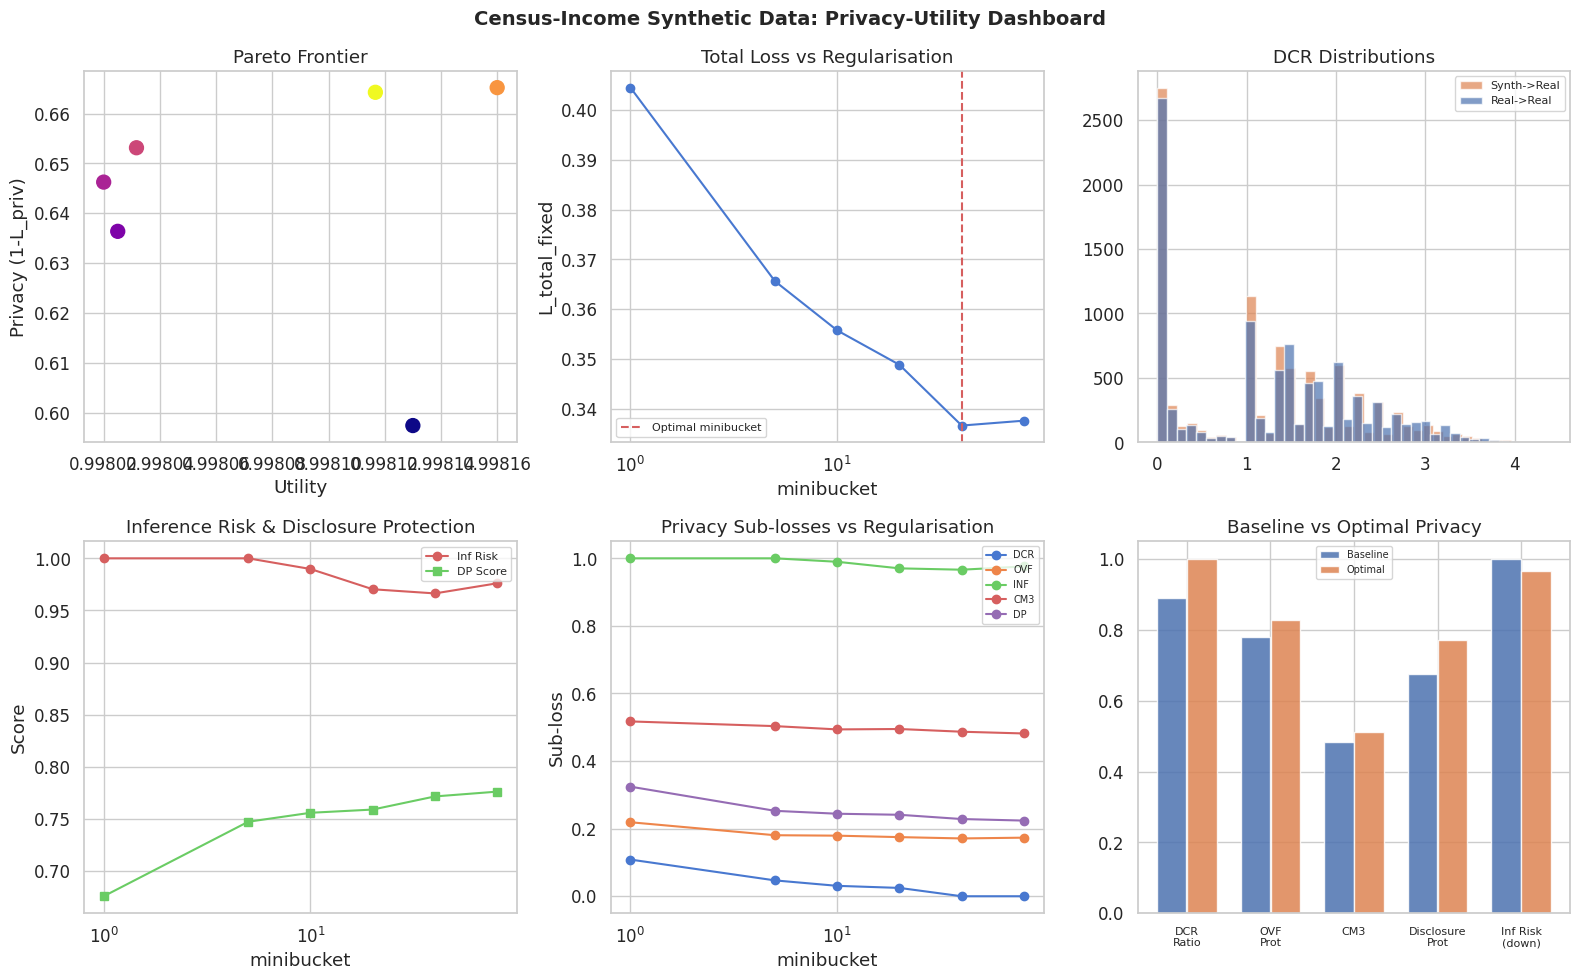


Analysis complete.


In [38]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Census-Income Synthetic Data: Privacy-Utility Dashboard', fontsize=14, fontweight='bold')

ax_tradeoff = fig.add_subplot(2, 3, 1)
ax_tradeoff.scatter(sweep_df['utility'], 1 - sweep_df['L_privacy'], c=sweep_df['lambda_p'], cmap='plasma', s=100)
ax_tradeoff.set_xlabel('Utility'); ax_tradeoff.set_ylabel('Privacy (1-L_priv)')
ax_tradeoff.set_title('Pareto Frontier')

ax_loss = fig.add_subplot(2, 3, 2)
ax_loss.plot(sweep_df['minibucket'], sweep_df['L_total_fixed'], 'o-b')
ax_loss.axvline(opt['minibucket'], color='r', linestyle='--', label='Optimal minibucket')
ax_loss.set_xscale('log')
ax_loss.set_xlabel('minibucket'); ax_loss.set_ylabel('L_total_fixed')
ax_loss.set_title('Total Loss vs Regularisation')
ax_loss.legend(fontsize=8)

ax_dcr = fig.add_subplot(2, 3, 3)
ax_dcr.hist(dcr_obj.distances, bins=40, color='#DD8452', alpha=0.7, label='Synth->Real')
ax_dcr.hist(dcr_obj.rr_distances, bins=40, color='#4C72B0', alpha=0.7, label='Real->Real')
ax_dcr.set_title('DCR Distributions'); ax_dcr.legend(fontsize=8)

ax_inf = fig.add_subplot(2, 3, 4)
ax_inf.plot(sweep_df['minibucket'], sweep_df['inference_risk'], 'o-r', label='Inf Risk')
ax_inf.plot(sweep_df['minibucket'], sweep_df['dp_score'], 's-g', label='DP Score')
ax_inf.set_xscale('log')
ax_inf.set_xlabel('minibucket'); ax_inf.set_ylabel('Score')
ax_inf.set_title('Inference Risk & Disclosure Protection')
ax_inf.legend(fontsize=8)

ax_sub = fig.add_subplot(2, 3, 5)
sub_loss_keys = ['dcr_sub_loss', 'ovf_sub_loss', 'inf_sub_loss', 'cm3_sub_loss', 'dp_sub_loss']
sub_lbl = ['DCR', 'OVF', 'INF', 'CM3', 'DP']
for col_i, lbl_i in zip(sub_loss_keys, sub_lbl):
    ax_sub.plot(sweep_df['minibucket'], sweep_df[col_i], 'o-', label=lbl_i)
ax_sub.set_xscale('log')
ax_sub.set_xlabel('minibucket'); ax_sub.set_ylabel('Sub-loss')
ax_sub.set_title('Privacy Sub-losses vs Regularisation')
ax_sub.legend(fontsize=7)

ax_comp = fig.add_subplot(2, 3, 6)
comp_x = np.arange(5)
comp_keys = ['dcr_ratio', 'ovf_protection', 'cm3_score', 'dp_score', 'inference_risk']
comp_lbl = ['DCR\nRatio', 'OVF\nProt', 'CM3', 'Disclosure\nProt', 'Inf Risk\n(down)']
ax_comp.bar(comp_x - 0.18, [base[k] for k in comp_keys], 0.35, label='Baseline', color='#4C72B0', alpha=0.85)
ax_comp.bar(comp_x + 0.18, [opt[k] for k in comp_keys], 0.35, label='Optimal', color='#DD8452', alpha=0.85)
ax_comp.set_xticks(comp_x); ax_comp.set_xticklabels(comp_lbl, fontsize=8)
ax_comp.set_title('Baseline vs Optimal Privacy'); ax_comp.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('\nAnalysis complete.')